# Multi-Objective Energy Dispatch Optimization

This notebook formulates and solves a **multi-objective Linear Programming (LP)** model to dispatch daily electricity generation in the **Valparaíso region** of Chile.

The model minimizes a weighted combination of two objectives:

| Objective | Weight | Description |
|---|---|---|
| Total operational cost | α = 0.9 | USD per MWh dispatched |
| Total CO₂e emissions | β = 0.1 | kg per MWh dispatched |

**Dispatchable resources:**
- **Thermal** plant (controllable generation)
- **BESS** — Battery Energy Storage System (charge / discharge)

Daily demand (`D_t`) comes from the LSTM forecasts produced in `Forecast_total_generation.ipynb`. The file `data/predictions_valparaiso_2023.parquet` must be present before running this notebook.

> **Note:** This is a simplified toy case. In the full study, solar and hydro generation are pre-dispatched and the LP receives only the residual net demand.

## 1. Import Libraries

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pulp

os.makedirs("figures", exist_ok=True)

## 2. Technology Parameters & Demand Data

### 2.1 Technology Parameters

The table below summarises the key parameters for each generation technology based on the Chilean electricity mix for the Valparaíso region. In the full study these values are loaded from `data_energetic_modelation.xlsx`; here they are embedded directly for self-contained reproducibility.

In [18]:
# Technology parameters (source: data_energetic_modelation.xlsx)
tech_params = pd.DataFrame({
    "Technology":        ["Hidráulica", "Solar",  "Eólica", "Térmica", "Biomasa", "Geotérmica", "BESS",  "Termosolar"],
    "Installed_MW":      [2_500,        5_000,    4_500,    12_600,    800,        100,           2_500,   300],
    "Cost_USD_per_MWh":  [70,           35,       45,       100,       75,         70,            12,      150],
    "CO2e_kg_per_MWh":   [24,           41,       11,       900,       0,          45,            0,       10],
})

tech_params

,Technology,Installed_MW,Cost_USD_per_MWh,CO2e_kg_per_MWh
0,Hidráulica,2500,70,24
1,Solar,5000,35,41
2,Eólica,4500,45,11
3,Térmica,12600,100,900
4,Biomasa,800,75,0
5,Geotérmica,100,70,45
6,BESS,2500,12,0
7,Termosolar,300,150,10


In [ ]:
# Extract BESS operational cost
bess = tech_params[tech_params["Technology"] == "BESS"].iloc[0]
COST_BESS = float(bess["Cost_USD_per_MWh"])   # USD/MWh cycled (G_BESS in the paper)

# BESS physical constraints — paper Appendix B.5
CAP_BESS_STORAGE = 10_000  # MWh — CapBESS (total energy storage capacity)
C_BAR            = 2_500   # MWh/day — maximum daily charge flow (C̄)
R_BAR            = 2_500   # MWh/day — maximum daily discharge flow (R̄)
ETA_CHARGE       = 0.92    # η_ch — charging efficiency
ETA_DISCHARGE    = 0.92    # η_dis — discharging efficiency (used as 1/η_dis in SOC constraint)
S0               = 5_000   # MWh — initial state of charge (50 % of CapBESS)

# Thermal plant parameters — paper Table 1
thermal = tech_params[tech_params["Technology"] == "Térmica"].iloc[0]
CAP_THERMAL  = float(thermal["Installed_MW"])       # MW
COST_THERMAL = float(thermal["Cost_USD_per_MWh"])   # USD/MWh
CO2_THERMAL  = float(thermal["CO2e_kg_per_MWh"])    # kgCO₂e/MWh

# Dispatch model constants
# Note: a 0.8 daily availability factor is applied to thermal capacity to account for
# planned/unplanned outages; this is conservative relative to the raw installed capacity.
# With peak demand of ~52,000 MWh/day, the thermal capacity constraint (241,920 MWh/day)
# is never binding — results are identical with or without this factor.
PLANT_FACTOR  = 0.8
HOURS_PER_DAY = 24
ALPHA         = 0.9   # cost weight in the weighted-sum objective
BETA          = 0.1   # emission weight  (α + β = 1)

MAX_THERMAL_MWH = CAP_THERMAL * PLANT_FACTOR * HOURS_PER_DAY  # MWh per day

print(f"Thermal max daily output : {MAX_THERMAL_MWH:>10,.0f} MWh")
print(f"BESS storage capacity    : {CAP_BESS_STORAGE:>10,.0f} MWh")
print(f"BESS max charge/discharge: {C_BAR:>10,.0f} MWh/day")
print(f"BESS initial SOC         : {S0:>10,.0f} MWh  ({S0/CAP_BESS_STORAGE:.0%} of capacity)")
print(f"Objective weights        : α = {ALPHA},  β = {BETA}")

### 2.2 Demand Data

Daily demand comes from the LSTM forecasts stored in `predictions_valparaiso_2023.parquet`. Each row represents one day and the `PREDICTION` column contains the forecasted total generation (MWh), which is used here as the dispatch target.

In [20]:
# Load LSTM predictions (output of Forecast_total_generation.ipynb)
df_demand = pd.read_parquet("data/predictions_valparaiso_2023.parquet")
df_demand["DATE"] = pd.to_datetime(df_demand["DATE"])
df_demand = df_demand.sort_values("DATE").reset_index(drop=True)

# Build demand dictionary indexed by date
D_t = df_demand.set_index("DATE")["PREDICTION"].to_dict()
T   = sorted(D_t.keys())

print(f"Optimization periods : {len(T)} days")
print(f"Date range           : {T[0].date()} → {T[-1].date()}")
print(f"Demand range         : {min(D_t.values()):>10,.0f} – {max(D_t.values()):,.0f} MWh/day")

Optimization periods : 304 days
Date range           : 2023-01-31 → 2023-11-30
Demand range         :     11,144 – 51,617 MWh/day


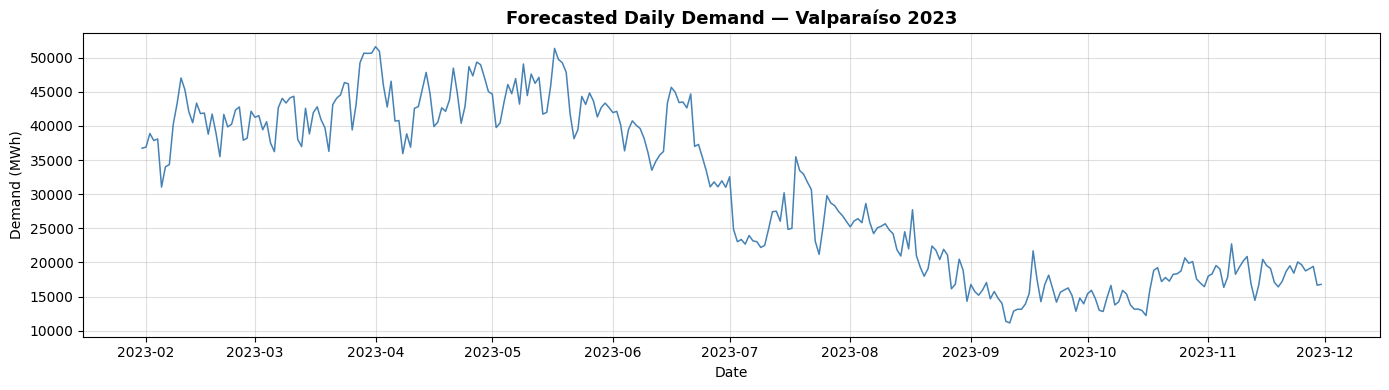

In [21]:
plt.figure(figsize=(14, 4))
plt.plot(df_demand["DATE"], df_demand["PREDICTION"], color="steelblue", linewidth=1.1)
plt.title("Forecasted Daily Demand — Valparaíso 2023", fontsize=13, weight="bold")
plt.xlabel("Date")
plt.ylabel("Demand (MWh)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/08_daily_demand.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Model Formulation

### Sets & Indices
- $T$ — set of daily periods $t = 1, \ldots, |T|$

### Parameters

| Symbol | Description |
|---|---|
| $D_t$ | Forecasted demand in period $t$ (MWh) |
| $\overline{P}$ | Maximum thermal energy per day (MWh) |
| $\overline{S}$ | BESS storage capacity (MWh) |
| $\overline{C},\, \overline{R}$ | BESS maximum daily charge / discharge (MWh/day) |
| $g^P,\, g^{\text{BESS}}$ | Variable costs — thermal, BESS (USD/MWh) |
| $e^P$ | CO₂e emission factor — thermal (kgCO₂e/MWh) |
| $\eta_c,\, \eta_d$ | BESS round-trip charge / discharge efficiency |
| $\alpha,\, \beta$ | Objective weights ($\alpha + \beta = 1$) |

### Decision Variables

| Variable | Domain | Description |
|---|---|---|
| $P_t \geq 0$ | $\mathbb{R}_{+}$ | Thermal dispatch in period $t$ (MWh) |
| $C_t \geq 0$ | $[0,\, \overline{C}]$ | BESS energy charged in period $t$ — grid side (MWh) |
| $R_t \geq 0$ | $[0,\, \overline{R}]$ | BESS energy discharged in period $t$ — grid side (MWh) |
| $S_t \geq 0$ | $[0,\, \overline{S}]$ | BESS state of charge at end of period $t$ (MWh) |

### Objective Function

$$
\min \quad Z = \alpha \underbrace{\left[ g^P \sum_t P_t + g^{\text{BESS}} \sum_t (C_t + R_t) \right]}_{\text{Total operating cost}} + \beta \underbrace{\left[ e^P \sum_t P_t \right]}_{\text{Total CO}_2\text{e emissions}}
$$

### Constraints

$$
(1)\quad P_t + R_t = D_t + C_t \qquad \forall t \in T \quad \text{(energy balance)}
$$
$$
(2)\quad 0 \leq P_t \leq \overline{P} \qquad \forall t \in T \quad \text{(thermal capacity)}
$$
$$
(3)\quad S_t = S_{t-1} + \eta_c\, C_t - \dfrac{1}{\eta_d}\, R_t \qquad \forall t \in T,\; S_0 = 5{,}000 \text{ MWh} \quad \text{(BESS state-of-charge)}
$$
$$
(4)\quad 0 \leq C_t \leq \overline{C},\quad 0 \leq R_t \leq \overline{R} \qquad \forall t \in T \quad \text{(charge/discharge limits)}
$$
$$
(5)\quad 0 \leq S_t \leq \overline{S} \qquad \forall t \in T \quad \text{(storage bounds)}
$$

> **Note on constraint (3):** $C_t$ and $R_t$ are grid-side flows. Charging $C_t$ MWh from the grid stores $\eta_c C_t$ in the battery; discharging $R_t$ MWh to the grid draws $R_t/\eta_d$ from storage. This is eq. (6) of the paper (Carrasco et al., 2026).

## 4. Model Implementation & Solution

The LP is implemented with **PuLP** using the open-source CBC solver.

In [ ]:
lp = pulp.LpProblem("MultiObjective_Energy_Dispatch", pulp.LpMinimize)

# --- Decision Variables ---
P = pulp.LpVariable.dicts("P", T, lowBound=0,                   cat="Continuous")
C = pulp.LpVariable.dicts("C", T, lowBound=0, upBound=C_BAR,    cat="Continuous")
R = pulp.LpVariable.dicts("R", T, lowBound=0, upBound=R_BAR,    cat="Continuous")
S = pulp.LpVariable.dicts("S", T, lowBound=0, upBound=CAP_BESS_STORAGE, cat="Continuous")

# --- Constraints ---
for t in T:
    # (1) Energy balance: thermal + BESS discharge = demand + BESS charge
    lp += P[t] + R[t] == D_t[t] + C[t],  f"balance_{t}"
    # (2) Thermal daily capacity
    lp += P[t] <= MAX_THERMAL_MWH,        f"capacity_{t}"

for i, t in enumerate(T):
    # (3) BESS state-of-charge — paper eq. (6), grid-side convention:
    #     charging C_t stores η_c·C_t; discharging R_t draws R_t/η_d from storage.
    s_prev = S0 if i == 0 else S[T[i - 1]]
    lp += S[t] == s_prev + ETA_CHARGE * C[t] - (1 / ETA_DISCHARGE) * R[t], f"bess_{t}"

# --- Objective Function ---
cost_expr      = pulp.lpSum(COST_THERMAL * P[t] + COST_BESS * (C[t] + R[t]) for t in T)
emissions_expr = pulp.lpSum(CO2_THERMAL  * P[t] for t in T)

lp += ALPHA * cost_expr + BETA * emissions_expr

# --- Solve (CBC, silent mode) ---
lp.solve(pulp.PULP_CBC_CMD(msg=0))

status = pulp.LpStatus[lp.status]
print(f"Solver status : {status}")
if status == "Optimal":
    total_cost      = pulp.value(cost_expr)
    total_emissions = pulp.value(emissions_expr)
    print(f"Total operational cost : USD {total_cost:>15,.2f}")
    print(f"Total CO₂e emissions   : kg  {total_emissions:>15,.2f}")

## 5. Results & Visualization

We extract the optimal solution and build a results DataFrame covering all dispatch periods.

In [ ]:
# Extract optimal solution into a results DataFrame
df_results = pd.DataFrame({
    "DATE":     T,
    "Demand":   [D_t[t]        for t in T],
    "Thermal":  [P[t].varValue for t in T],
    "BESS_Ch":  [C[t].varValue for t in T],
    "BESS_Dis": [R[t].varValue for t in T],
    "BESS_SOC": [S[t].varValue for t in T],
})
df_results["Daily_Cost"]      = COST_THERMAL * df_results["Thermal"]
df_results["Daily_Emissions"] = CO2_THERMAL  * df_results["Thermal"]

df_results.set_index("DATE", inplace=True)
df_results[["Demand", "Thermal", "Daily_Cost", "Daily_Emissions"]].round(1).head(10)

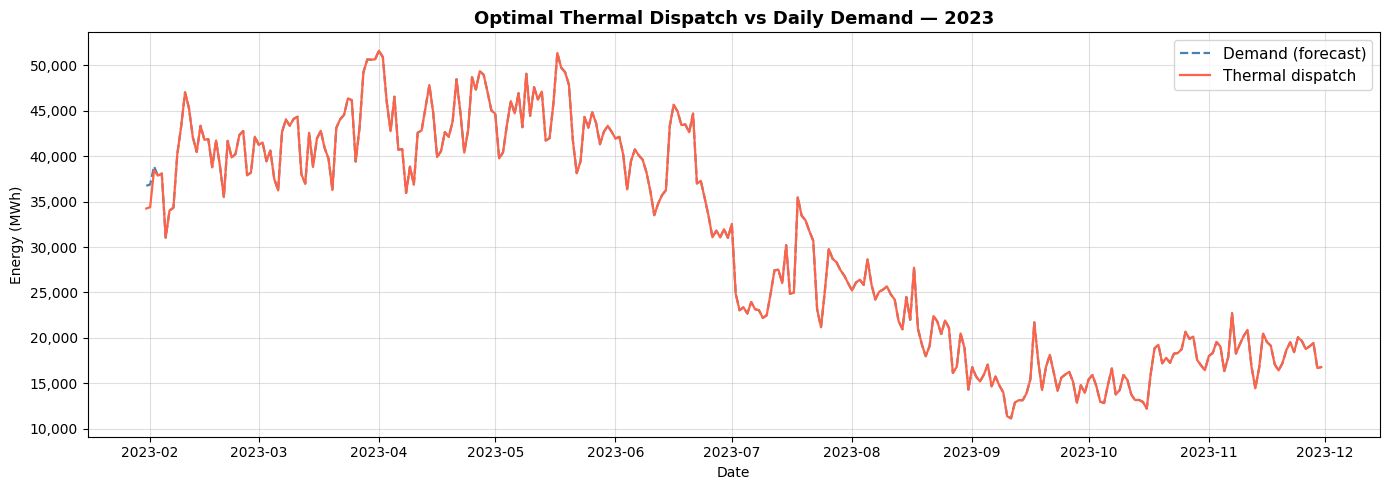

In [ ]:
# --- Thermal dispatch vs demand ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_results.index, df_results["Demand"],  label="Demand (forecast)",    linestyle="--", color="steelblue",  linewidth=1.6)
ax.plot(df_results.index, df_results["Thermal"], label="Thermal dispatch",     color="tomato",     linewidth=1.6)
ax.set_title("Optimal Thermal Dispatch vs Daily Demand — 2023", fontsize=13, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Energy (MWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/09_thermal_dispatch.png", dpi=150, bbox_inches="tight")
plt.show()

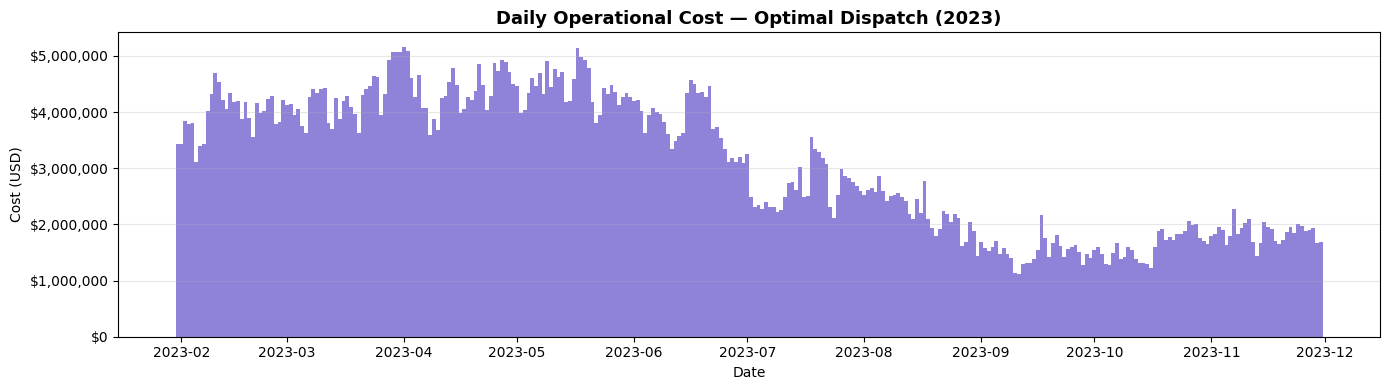

In [25]:
# --- Daily operational cost ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df_results.index, df_results["Daily_Cost"], color="slateblue", alpha=0.75, width=1)
ax.set_title("Daily Operational Cost — Optimal Dispatch (2023)", fontsize=13, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Cost (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figures/10_daily_cost.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Summary statistics — generation-weighted national aggregate figures from the paper
# are 21.7 % cost reduction, 42.5 % CO₂ reduction, 22.9 % thermal reduction.
# Single-region (Valparaíso) results below are directionally consistent.
summary = pd.DataFrame({
    "Metric": [
        "Optimization periods (days)",
        "Total thermal dispatch (MWh)",
        "Total operational cost (USD)",
        "Total CO₂e emissions (kg)",
        "Average daily cost (USD/day)",
        "Average CO₂e intensity (kg/MWh)",
    ],
    "Value": [
        f"{len(T)}",
        f"{df_results['Thermal'].sum():>15,.1f}",
        f"{total_cost:>15,.2f}",
        f"{total_emissions:>15,.2f}",
        f"{df_results['Daily_Cost'].mean():>15,.2f}",
        f"{total_emissions / df_results['Thermal'].sum():>15.2f}",
    ]
})
summary

## 6. Reproducibility Notes

The LP results in this notebook are **fully deterministic**: given the same `data/predictions_valparaiso_2023.parquet` input file, the CBC solver produces identical output on any platform.

The pre-computed predictions file (included in the repository) was generated by `Forecast_total_generation.ipynb` with `SEED = 42`. If Stage 1 is re-run, stochastic LSTM initialization may produce slightly different forecasts (see the reproducibility section of `Forecast_total_generation.ipynb`), which in turn will cause small numerical differences in the LP dispatch results. The paper-level results (21.7% cost reduction, 42.5% CO₂ reduction, 22.9% thermal reduction) are generation-weighted national aggregates across all 14 regions and are not directly reproduced by this single-region case study — they are provided as a reference benchmark.